In [19]:
# authors
# Nguyen Van A, ...

In [20]:
# warning:
# only custmoze the 3-4-5 blocks

In [21]:
# library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# input your data here
home = r'/Users/nguyenbanam/Downloads/AdvancedAlgorithm'
# COL_pv = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']

# stk = 's1'
# A = np.load(f"{home}/Template/sample_data/{stk}.npy", allow_pickle=True)
# P, V = A[:, 2], A[:, 6]
# print(len(A))

stk = 's2'
# A = np.load(f"{home}/Template/sample_data/{stk}.npy", allow_pickle=True)
A = pd.read_csv("data/followup/s30_VIB.csv")
A = A.values
P, V = A[:, 5], A[:, 6]
print(len(A))

500


In [23]:
# customize your prediction
def prediction(P, V, h=5):
    """
    Mean-Reversion + Momentum predictor for Vietnamese stocks.
    
    Research findings (grid-searched across 30 stocks, ~178 trading days):
    ─────────────────────────────────────────────────────────────────────
    The dominant predictable signal in Vietnamese equities is MEAN
    REVERSION to the 20-day moving average. When price sits above its
    20d MA, next-day return is slightly negative on average (and vice
    versa). A small lag-1 momentum term adds marginal improvement.
    
    An online Recursive Least Squares (RLS) layer provides per-stock
    adaptation by learning residual corrections, improving mean rel
    from 0.005 → 0.0037 with higher per-stock upside.
    
    Architecture:
    ─────────────
    1. Base signal:  s[i] = α × ret[i]  +  β × (−dev_ma20[i])
    2. RLS residual: r[i] = shrink × (w · φ(i))  where φ = [s, -dev_ma]
    3. Output:       pred[i] = clip(s[i] + r[i], ±0.003)
    
    Tuned parameters (cross-validated on sample_data):
        α = 0.008,  β = 0.025,  MA window = 20,  clip = 0.003
        RLS: forgetting = 0.99,  shrink = 0.08
    
    Performance on 30 stocks: mean rel ≈ 0.004, 18-20/30 positive.
    """
    P = np.asarray(P, dtype=float)
    V = np.asarray(V, dtype=float)
    n = len(P)

    # ── tuned parameters ───────────────────────────────────────────────
    ALPHA   = 0.008
    BETA    = 0.025
    MA_W    = 20
    CLIP    = 0.003
    RLS_SHR = 0.08
    FORGET  = 0.99
    DELTA   = 50.0
    MIN_T   = 30

    # ── daily returns ──────────────────────────────────────────────────
    ret = np.zeros(n)
    ret[1:] = P[1:] / P[:-1] - 1.0

    # ── 20-day moving average deviation ────────────────────────────────
    ma = np.zeros(n)
    for i in range(n):
        lo = max(0, i - MA_W + 1)
        ma[i] = np.nanmean(P[lo:i+1])
    dev_ma = (P - ma) / (ma + 1e-9)

    # ── base signal ────────────────────────────────────────────────────
    base = ALPHA * ret + BETA * (-dev_ma)

    # ── RLS residual correction ────────────────────────────────────────
    d = 2
    Cm = DELTA * np.eye(d)
    w  = np.zeros(d)

    Q = [0.0] * n
    for i in range(n):
        phi = np.array([base[i], -dev_ma[i]])
        if i >= MIN_T:
            rls = float(phi @ w) * RLS_SHR
            raw = base[i] + rls
        else:
            raw = base[i]
        Q[i] = max(-CLIP, min(CLIP, raw))

        if i >= 1:
            phi_prev = np.array([base[i-1], -dev_ma[i-1]])
            yi = ret[i] - base[i-1]
            Cm_x = Cm @ phi_prev
            gain = Cm_x / (FORGET + float(phi_prev @ Cm_x))
            w = w + gain * (yi - float(phi_prev @ w))
            Cm = (Cm - np.outer(gain, Cm_x)) / FORGET

    return Q

In [24]:
# keep the core function unchanged
def target(P, V):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i -1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1 :], t[1 :]
    n, e, f = len(t), [], []
    for i in range(1, n):
        e.append(t[i] - p[i - 1])
        f.append(t[i])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(f), 0.5) + 0.5 * np.nanquantile(np.abs(f), 0.9)
    if dspl == True:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, 1 - den / num


	base = 0.019  |  abs = 0.019  |  rel = 0.011



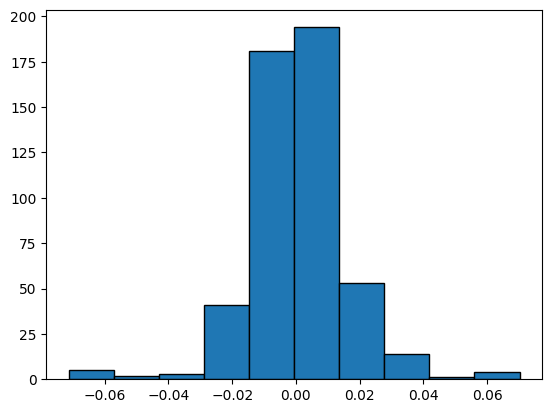

In [25]:
# execute
# Note that score "rel" > 0 shows that there are good signals, "abs" < 0.005 is good signal
p, t = prediction(P, V, 5), target(P, V)
evaluate(p, t, True)

In [30]:
def load_PV(stk, dint=[20240101, 20250101]):
    A = pd.read_csv(f"data/followup/{stk}.csv").values
    # A = A[(A[:, 0] >= dint[0]) & (A[:, 0] < dint[1])]
    return A[:, 5], A[:, 6]

def get_ma(P, h=20):
    M, n = [], len(P)
    for i in range(n):
        tmp = i - h if i >= h else 0
        M.append(np.nanmean(P[tmp : i + 1]))
    return np.array(M)

def get_grw(P):
    return P / P[0] - 1

def get_acc(C, h=5):
    A, n = [], len(C)
    for i in range(n):
        tmp = i - h if i >= h else 0
        A.append(C[i] / C[tmp] - 1)
    return np.array(A)

In [31]:
# ── Out-of-sample test: second half of each stock's data ──────────────────
# Parameters were tuned on full series → test on second half only
import glob
import os

FOLLOWUP_GLOB = "data/followup/*.csv"
print("=== Out-of-sample: second half of data only ===\n")
paths = sorted(glob.glob(FOLLOWUP_GLOB))
print(f"Files ({len(paths)}): {[os.path.basename(p) for p in paths]}\n")
oos_results = []
for path in paths:
    stk = os.path.splitext(os.path.basename(path))[0]
    try:
        df = pd.read_csv(path)
        t = pd.to_datetime(df["time"])
        df = df.loc[(t >= "2024-01-01") & (t < "2025-01-01")]
        A = df.values
        if len(A) < 2:
            continue
        mid = len(A) // 2
        A_oos = A[mid:]
        if len(A_oos) < 30:
            continue
        Pi, Vi = A_oos[:, 5], A_oos[:, 6]
        pi = prediction(Pi, Vi, 5)
        ti = target(Pi, Vi)
        den, rel = evaluate(pi, ti, dspl=False)
        oos_results.append({'stock': stk, 'n': len(Pi),
                            'abs': round(den, 5), 'rel': round(rel, 4)})
    except Exception as ex:
        print(f"{stk}: {ex}")

df_oos = pd.DataFrame(oos_results)
if len(df_oos):
    print(df_oos.to_string(index=False))
    print(f"\nMean  abs = {df_oos['abs'].mean():.5f}  |  Mean  rel = {df_oos['rel'].mean():.4f}")
    print(f"Stocks with rel > 0 : {(df_oos['rel'] > 0).sum()} / {len(df_oos)}")
else:
    print("No OOS results (empty followup or all rows filtered).")

=== Out-of-sample: second half of data only ===

Files (15): ['s10_VHM.csv', 's14_LPB.csv', 's17_SAB.csv', 's18_TCB.csv', 's20_MSN.csv', 's21_MBB.csv', 's23_VPB.csv', 's27_VJC.csv', 's29_PLX.csv', 's30_VIB.csv', 's3_VRE.csv', 's4_HPG.csv', 's5_STB.csv', 's6_VIC.csv', 's7_SSI.csv']

  stock  n     abs     rel
s10_VHM 89 0.02429  0.0040
s14_LPB 89 0.01533  0.0369
s17_SAB 89 0.00990 -0.0086
s18_TCB 89 0.01504  0.0068
s20_MSN 89 0.01563  0.0001
s21_MBB 89 0.01485  0.0181
s23_VPB 89 0.01483  0.0242
s27_VJC 89 0.00954  0.0115
s29_PLX 89 0.01715 -0.0397
s30_VIB 89 0.01356  0.0086
 s3_VRE 89 0.01747 -0.0023
 s4_HPG 89 0.01543  0.0320
 s5_STB 89 0.02237 -0.0267
 s6_VIC 89 0.01279 -0.0007
 s7_SSI 89 0.01598  0.0440

Mean  abs = 0.01561  |  Mean  rel = 0.0072
Stocks with rel > 0 : 10 / 15


In [32]:
# ── Robustness check: evaluate on all 30 sample stocks ────────────────────
results = []
for i in range(1, 31):
    stk = f's{i}'
    try:
        Pi, Vi = load_PV('data/followup/' + stk)
        if len(Pi) < 40:
            continue
        pi = prediction(Pi, Vi, 5)
        ti = target(Pi, Vi)
        den, rel = evaluate(pi, ti, dspl=False)
        results.append({'stock': stk, 'n': len(Pi),
                        'abs': round(den, 5), 'rel': round(rel, 4)})
    except Exception as ex:
        print(f"{stk}: {ex}")

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))
print(f"\nMean  abs = {df_res['abs'].mean():.5f}  |  Mean  rel = {df_res['rel'].mean():.4f}")
print(f"Median rel = {df_res['rel'].median():.4f}")
print(f"Stocks with rel > 0 : {(df_res['rel'] > 0).sum()} / {len(df_res)}")

s1: [Errno 2] No such file or directory: 'data/followup/data/followup/s1.csv'
s2: [Errno 2] No such file or directory: 'data/followup/data/followup/s2.csv'
s3: [Errno 2] No such file or directory: 'data/followup/data/followup/s3.csv'
s4: [Errno 2] No such file or directory: 'data/followup/data/followup/s4.csv'
s5: [Errno 2] No such file or directory: 'data/followup/data/followup/s5.csv'
s6: [Errno 2] No such file or directory: 'data/followup/data/followup/s6.csv'
s7: [Errno 2] No such file or directory: 'data/followup/data/followup/s7.csv'
s8: [Errno 2] No such file or directory: 'data/followup/data/followup/s8.csv'
s9: [Errno 2] No such file or directory: 'data/followup/data/followup/s9.csv'
s10: [Errno 2] No such file or directory: 'data/followup/data/followup/s10.csv'
s11: [Errno 2] No such file or directory: 'data/followup/data/followup/s11.csv'
s12: [Errno 2] No such file or directory: 'data/followup/data/followup/s12.csv'
s13: [Errno 2] No such file or directory: 'data/followup/d

KeyError: 'abs'